In [126]:
# Cell 1: Install all required libraries
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud pyreadr scipy --quiet

print("✅ All libraries installed!")

✅ All libraries installed!


In [127]:
# Cell 2: Import libraries and set Tufte style
# All plots will follow these rules automatically

import os
import re
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud
import pyreadr

# ── Tufte Global Style ────────────────────────────────────────────
# NO color — black, white and grey only
# Consistent font, size and weight throughout
# No grid, no top/right borders, minimal ticks

plt.rcParams.update({
    # Font — serif throughout, consistent sizes
    'font.family'        : 'serif',
    'font.size'          : 11,
    'axes.titlesize'     : 12,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 10,
    'xtick.labelsize'    : 9,
    'ytick.labelsize'    : 9,

    # No chartjunk
    'axes.grid'          : False,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.linewidth'     : 0.7,
    'axes.edgecolor'     : '#333333',

    # Minimal ticks
    'xtick.major.size'   : 3,
    'ytick.major.size'   : 3,
    'xtick.major.width'  : 0.6,
    'ytick.major.width'  : 0.6,
    'xtick.direction'    : 'out',
    'ytick.direction'    : 'out',

    # Clean white background
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'figure.dpi'         : 130,
    'savefig.dpi'        : 150,
    'savefig.bbox'       : 'tight',

    # Lines
    'lines.linewidth'    : 1.6,
    'lines.markersize'   : 4,

    # Legend — clean, no frame
    'legend.frameon'     : False,
    'legend.fontsize'    : 9,
})

# ── Grey palette — no color, only shades of grey ─────────────────
DARK    = '#111111'   # titles, trend lines
MID     = '#555555'   # main data elements
LIGHT   = '#999999'   # secondary elements
XLIGHT  = '#CCCCCC'   # backgrounds, bands
WHITE   = '#FFFFFF'   # box fills

# ── Helper functions ──────────────────────────────────────────────
def despine(ax):
    """Remove top and right borders — Tufte data-ink ratio."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def direct_label(ax, x, y, text, offset_y=0, size=8):
    """Write value directly on the chart — Tufte direct labeling."""
    ax.text(x, y + offset_y, text,
            ha='center', va='bottom',
            fontsize=size, color=DARK)

print("✅ Libraries imported!")
print("✅ Tufte style configured!")
print()
print("Design rules active:")
print("  → No color         : black, white and grey only")
print("  → Font             : serif, consistent sizes")
print("  → No grid          : no chartjunk")
print("  → Direct labeling  : values written on chart")
print("  → No top/right borders")


✅ Libraries imported!
✅ Tufte style configured!

Design rules active:
  → No color         : black, white and grey only
  → Font             : serif, consistent sizes
  → No grid          : no chartjunk
  → Direct labeling  : values written on chart
  → No top/right borders


In [128]:
# Cell 3: Load the R metadata file (DAV_assignment.rds)
# This contains: company name, year, sector, country, size etc.

RDATA_FILE    = 'DAV_assignment.rds'
TXT_FOLDER    = 'txt_converted'
OUTPUT_FOLDER = 'outputs'
N_REPORTS     = 1000
RANDOM_SEED   = 42

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Load RDS file
rdata   = pyreadr.read_r(RDATA_FILE)
meta_df = list(rdata.values())[0]

print("✅ Metadata loaded!")
print()
print(f"  Rows    : {meta_df.shape[0]:,}")
print(f"  Columns : {meta_df.shape[1]}")
print()
print("Columns available:")
for col in meta_df.columns:
    print(f"  → {col}")

print()
print("Preview:")
meta_df.head(3)


✅ Metadata loaded!

  Rows    : 19,040
  Columns : 11

Columns available:
  → Name
  → Year
  → file
  → Organization_type
  → Size
  → Sector
  → Sec_SASB
  → Country
  → Region
  → OECD
  → english_non_english

Preview:


,Name,Year,file,Organization_type,Size,Sector,Sec_SASB,Country,Region,OECD,english_non_english
0,Procter & Gamble,1999.0,Procter&Gamble_1999,NaN,Large,Household and Personal Products,Consumer Goods,United States of America,Northern America,NaN,english
1,Banrisul,2000.0,Banrisul_2000,NaN,Large,Financial Services,Financials,Brazil,Latin America & the Caribbean,NaN,non-english
2,Hitachi High-Technologies Corp.,2000.0,HitachiHigh-TechnologiesCorp._2000,NaN,MNE,Conglomerates,Conglomerates,Japan,Asia,NaN,english


In [129]:
# Cell 4: Load English reports only
# Step 1: Filter metadata to English only
# Step 2: Match with txt files in folder
# Step 3: Sample 1000 reports

# Step 1 — Filter English only
meta_english = meta_df[meta_df['english_non_english'] == 'english'].copy()
meta_english = meta_english.reset_index(drop=True)

print(f"Total reports in metadata      : {meta_df.shape[0]:,}")
print(f"English reports                : {meta_english.shape[0]:,}")
print(f"Non-English excluded           : {meta_df.shape[0] - meta_english.shape[0]:,}")
print()

# Step 2 — Get English filenames
english_filenames = set(meta_english['file'].astype(str).tolist())

# Find all txt files
all_txt = list(set(
    glob.glob(os.path.join(TXT_FOLDER, '**', '*.txt'), recursive=True) +
    glob.glob(os.path.join(TXT_FOLDER, '*.txt'))
))

# Match txt files to English filenames
english_txt = [
    f for f in all_txt
    if os.path.basename(f).replace('.txt', '') in english_filenames
]

print(f"Matching English txt files     : {len(english_txt):,}")
print()

# Step 3 — Sample 1000
if len(english_txt) > N_REPORTS:
    np.random.seed(RANDOM_SEED)
    english_txt = list(np.random.choice(english_txt, N_REPORTS, replace=False))
    print(f"Randomly sampled               : {N_REPORTS:,} reports")

# Step 4 — Read files
print("Reading files... ⏳")
records = []
for fpath in english_txt:
    try:
        with open(fpath, 'r', encoding='utf-8', errors='ignore') as f:
            text = f.read()
        records.append({
            'filename'     : os.path.basename(fpath),
            'filename_key' : os.path.basename(fpath).replace('.txt', ''),
            'raw_text'     : text
        })
    except Exception:
        pass

df = pd.DataFrame(records)
print(f"✅ Loaded {len(df):,} English reports!")
print()
print("Preview:")
df[['filename', 'raw_text']].head(3)


Total reports in metadata      : 19,040
English reports                : 9,935
Non-English excluded           : 9,105

Matching English txt files     : 1,653

Randomly sampled               : 1,000 reports
Reading files... ⏳
✅ Loaded 1,000 English reports!

Preview:


,filename,raw_text
0,KirinHoldings_2017.txt,env i ro n m e nt al re p o r t 2017\n ...
1,FujiHeavyIndustries(Subaru)_2017.txt,csr report\ncorporate social respo...
2,Camfil_2014.txt,sustainability report 2014\n\n\n...


In [130]:
# Cell 5: Merge metadata onto reports and select only needed variables
# We only keep columns relevant to our research questions:
# → Year     : for trend analysis (RQ2)
# → Sector   : for theme comparison across industries
# → Country  : for geographic context
# → Size     : for company size comparison
# → Region   : for regional trends

# Step 1 — Merge metadata
df = df.merge(
    meta_english[['file', 'Year', 'Sector', 'Country', 
                  'Region', 'Size', 'Organization_type']],
    left_on  = 'filename_key',
    right_on = 'file',
    how      = 'left'
)

# Step 2 — Rename for convenience
df = df.rename(columns={'Year': 'year'})

# Step 3 — Select only variables we need
df = df[['filename_key', 'raw_text', 'year', 
         'Sector', 'Country', 'Region', 
         'Size', 'Organization_type']].copy()

# Step 4 — Clean year column
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df         = df.dropna(subset=['year'])
df['year'] = df['year'].astype(int)

print("✅ Metadata merged and variables selected!")
print()
print(f"  Total reports          : {len(df):,}")
print(f"  Year range             : {df['year'].min()} – {df['year'].max()}")
print(f"  Sectors                : {df['Sector'].nunique()}")
print(f"  Countries              : {df['Country'].nunique()}")
print(f"  Company sizes          : {df['Size'].unique().tolist()}")
print()
print("Selected variables:")
for col in df.columns:
    non_null = df[col].notna().sum()
    print(f"  → {col:<20} {non_null:,} non-null values")
print()
print("Preview:")
df.head(3)


✅ Metadata merged and variables selected!

  Total reports          : 1,000
  Year range             : 2002 – 2018
  Sectors                : 38
  Countries              : 61
  Company sizes          : ['Large', 'MNE', 'SME']

Selected variables:
  → filename_key         1,000 non-null values
  → raw_text             1,000 non-null values
  → year                 1,000 non-null values
  → Sector               1,000 non-null values
  → Country              1,000 non-null values
  → Region               1,000 non-null values
  → Size                 1,000 non-null values
  → Organization_type    910 non-null values

Preview:


,filename_key,raw_text,year,Sector,Country,Region,Size,Organization_type
0,KirinHoldings_2017,env i ro n m e nt al re p o r t 2017\n ...,2017,Food and Beverage Products,Japan,Asia,Large,Private company
1,FujiHeavyIndustries(Subaru)_2017,csr report\ncorporate social respo...,2017,Automotive,Japan,Asia,MNE,Private company
2,Camfil_2014,sustainability report 2014\n\n\n...,2014,Other,Sweden,Europe,MNE,Private company


In [131]:
# Cell 6: Full text cleaning pipeline
# Raw text has: \n newlines, ..... dots, extra spaces, 
# numbers, symbols, URLs — we remove all of it

lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

# Domain stopwords — appear in every CSR report, carry no meaning
stop_words.update({
    'company', 'report', 'annual', 'year', 'group', 'data',
    'information', 'also', 'us', 'may', 'one', 'new', 'use',
    'used', 'using', 'total', 'number', 'page', 'table',
    'figure', 'sustainability', 'corporate', 'social',
    'responsibility', 'csr', 'gri', 'global', 'reporting',
    'management', 'business', 'performance'
})

def clean_text(text):
    """
    Full cleaning pipeline:
    1. Lowercase
    2. Remove URLs, emails, numbers, symbols
    3. Remove extra whitespace
    4. Tokenize
    5. Remove stopwords
    6. Lemmatize
    """
    text = str(text).lower()                            # 1. lowercase
    text = re.sub(r'http\S+|www\.\S+',  ' ', text)     # 2. remove URLs
    text = re.sub(r'\S+@\S+',           ' ', text)     # 3. remove emails
    text = re.sub(r'\.{2,}',            ' ', text)     # 4. remove ......
    text = re.sub(r'\b\d+\b',           ' ', text)     # 5. remove numbers
    text = re.sub(r'[^a-z\s]',          ' ', text)     # 6. letters only
    text = re.sub(r'\s+',               ' ', text).strip() # 7. whitespace

    tokens = word_tokenize(text)                        # 8. tokenize
    tokens = [t for t in tokens if t.isalpha()]         # 9. letters only
    tokens = [t for t in tokens if len(t) > 2]         # 10. min 3 chars
    tokens = [t for t in tokens if t not in stop_words]# 11. stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens] # 12. lemmatize

    return ' '.join(tokens)

print("Cleaning 1,000 reports... ⏳ (2-4 minutes)")
df['clean_text']       = df['raw_text'].apply(clean_text)
df['word_count_raw']   = df['raw_text'].apply(lambda t: len(str(t).split()))
df['word_count_clean'] = df['clean_text'].apply(lambda t: len(t.split()))

# Remove very short documents after cleaning
before  = len(df)
df      = df[df['word_count_clean'] >= 50].reset_index(drop=True)

# Remove duplicates
df['text_hash'] = df['clean_text'].apply(lambda t: hash(t[:200]))
df              = df.drop_duplicates(subset='text_hash').reset_index(drop=True)

print("✅ Cleaning complete!")
print()
print(f"  Reports before cleaning  : {before:,}")
print(f"  Reports after cleaning   : {len(df):,}")
print(f"  Avg words before         : {df['word_count_raw'].mean():,.0f}")
print(f"  Avg words after          : {df['word_count_clean'].mean():,.0f}")
print(f"  Reduction                : {(1 - df['word_count_clean'].mean()/df['word_count_raw'].mean())*100:.1f}%")
print()
print("Preview of clean text:")
print(df['clean_text'].iloc[0][:200])


Cleaning 1,000 reports... ⏳ (2-4 minutes)
✅ Cleaning complete!

  Reports before cleaning  : 1,000
  Reports after cleaning   : 972
  Avg words before         : 26,703
  Avg words after          : 14,188
  Reduction                : 46.9%

Preview of clean text:
env content environmental container packaging risk opportunity vision commitment target progress top message cardboard packaging pet bottle can glass bottle kirin long term environmental vision warmin


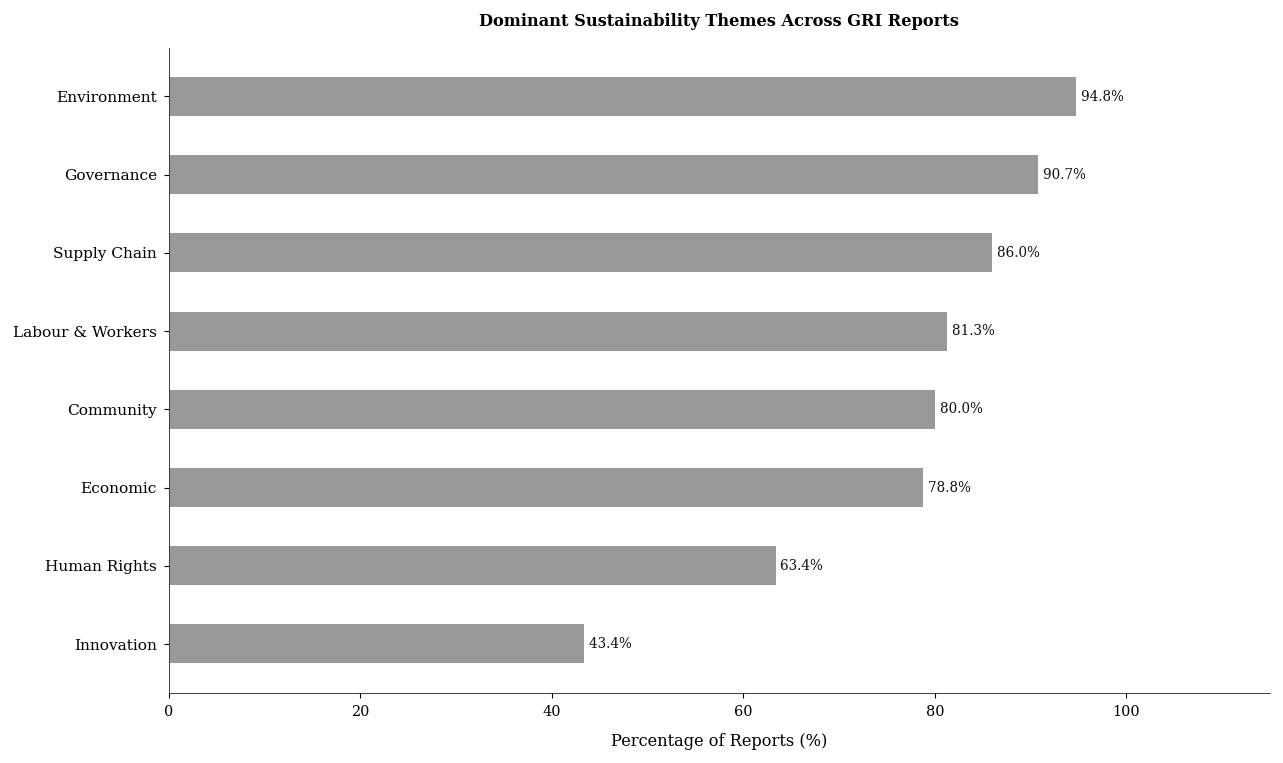

✅ Saved plot3_themes.png


In [141]:
# Cell 7 Figure 3 — Theme Frequency Bar Chart
# Tufte fixes:
# ✅ Lighter bars, no borders
# ✅ Thin axes only
# ✅ Smaller label font
# ✅ Short title
# ✅ No decoration

theme_plot = theme_df.sort_values('Documents', ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 6))

# Lighter bars — no borders
ax.barh(theme_plot['Theme'],
        theme_plot['Pct'],
        color=LIGHT,        # ✅ lighter than before
        edgecolor='none',
        height=0.5)          # ✅ slightly thinner bars

# Smaller font labels
for _, row in theme_plot.iterrows():
    ax.text(row['Pct'] + 0.5,
            row['Theme'],
            f"{row['Pct']:.1f}% ",
            va='center', ha='left',
            fontsize=7.5,    # ✅ smaller font
            color=DARK)

ax.set_xlim(0, 115)
ax.set_xlabel('Percentage of Reports (%)', fontsize=9, labelpad=8)

# Short title — no "Figure 3"
ax.set_title('Dominant Sustainability Themes Across GRI Reports',
             fontsize=9, pad=12)

ax.tick_params(axis='y', labelsize=8.5)  # ✅ smaller tick font
ax.tick_params(axis='x', labelsize=8)

# Thin axes only
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

despine(ax)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'plot3_themes.png'), bbox_inches='tight')
plt.show()
print("✅ Saved plot3_themes.png")

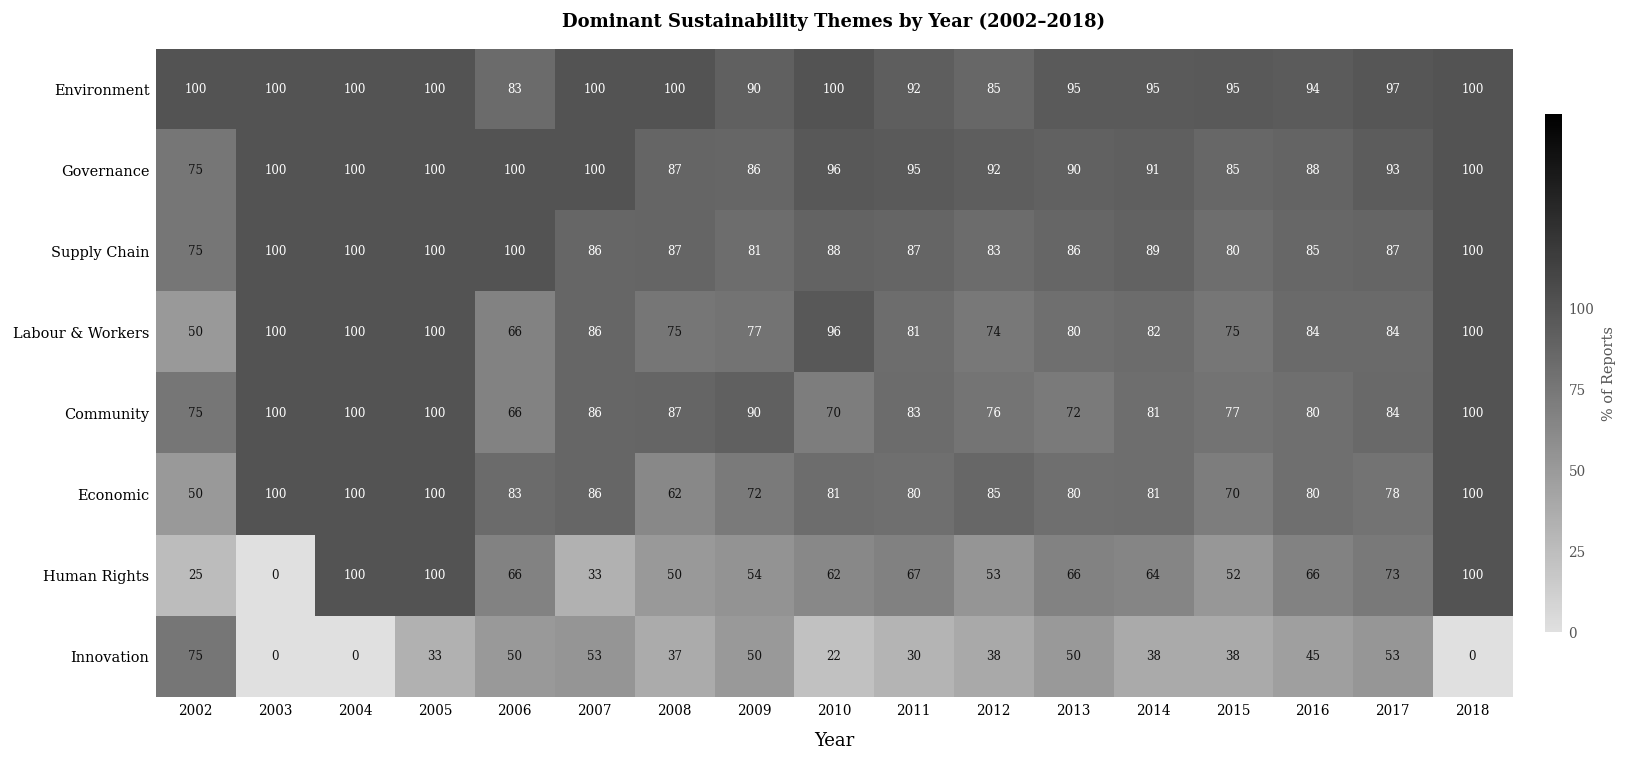

✅ Saved plot5_heatmap.png


In [133]:
# Cell 8 Figure 5 — Heatmap (Tufte Fixed)
# ✅ Lighter grey scale
# ✅ Zero cells = faint grey #e0e0e0 not white
# ✅ No tick marks
# ✅ No spines
# ✅ Minimal colorbar right side
# ✅ Clean title

from matplotlib.colors import LinearSegmentedColormap

# Custom grey colormap — faint grey for zeros, not white
custom_grey = LinearSegmentedColormap.from_list(
    'custom_grey',
    ['#e0e0e0', '#000000'],
    N=256)

valid_years  = sorted(df['year'].unique())
heatmap_data = []

for year in valid_years:
    df_year = df[df['year'] == year]
    row     = {'year': year}
    for theme, keywords in THEMES.items():
        count = 0
        for text in df_year['clean_text']:
            words = set(text.split())
            if len(words.intersection(set(keywords))) >= MIN_MATCHES:
                count += 1
        row[theme] = count / len(df_year) * 100
    heatmap_data.append(row)

heatmap_df  = pd.DataFrame(heatmap_data).set_index('year')
theme_order = theme_df.sort_values('Documents', ascending=False)['Theme'].tolist()
heatmap_df  = heatmap_df[theme_order]

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(heatmap_df.T.values,
               aspect='auto',
               cmap=custom_grey,
               vmin=0, vmax=160,
               interpolation='nearest')

# Cell value labels
for i, theme in enumerate(theme_order):
    for j, year in enumerate(valid_years):
        val       = heatmap_df.loc[year, theme]
        txt_color = WHITE if val > 75 else DARK
        ax.text(j, i, f'{int(val)}',
                ha='center', va='center',
                fontsize=6.5, color=txt_color)

ax.set_xticks(range(len(valid_years)))
ax.set_xticklabels(valid_years, rotation=0, fontsize=7.5)
ax.set_yticks(range(len(theme_order)))
ax.set_yticklabels(theme_order, fontsize=8)
ax.set_xlabel('Year', fontsize=10, labelpad=8)
ax.set_title('Dominant Sustainability Themes by Year (2002–2018)',
             fontsize=10, pad=12)

# No spines, no tick marks
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis='both', length=0)

# Minimal colorbar — right side, thin, no border
cbar = plt.colorbar(im, ax=ax,
                    shrink=0.8,
                    pad=0.02,
                    aspect=30)
cbar.set_label('% of Reports', fontsize=8, color=MID)
cbar.ax.tick_params(labelsize=7.5, length=0, color=MID)
cbar.outline.set_visible(False)       # ✅ no border
cbar.set_ticks([0, 25, 50, 75, 100])
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=MID)



plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'plot5_heatmap.png'),
            bbox_inches='tight')
plt.show()
print("✅ Saved plot5_heatmap.png")

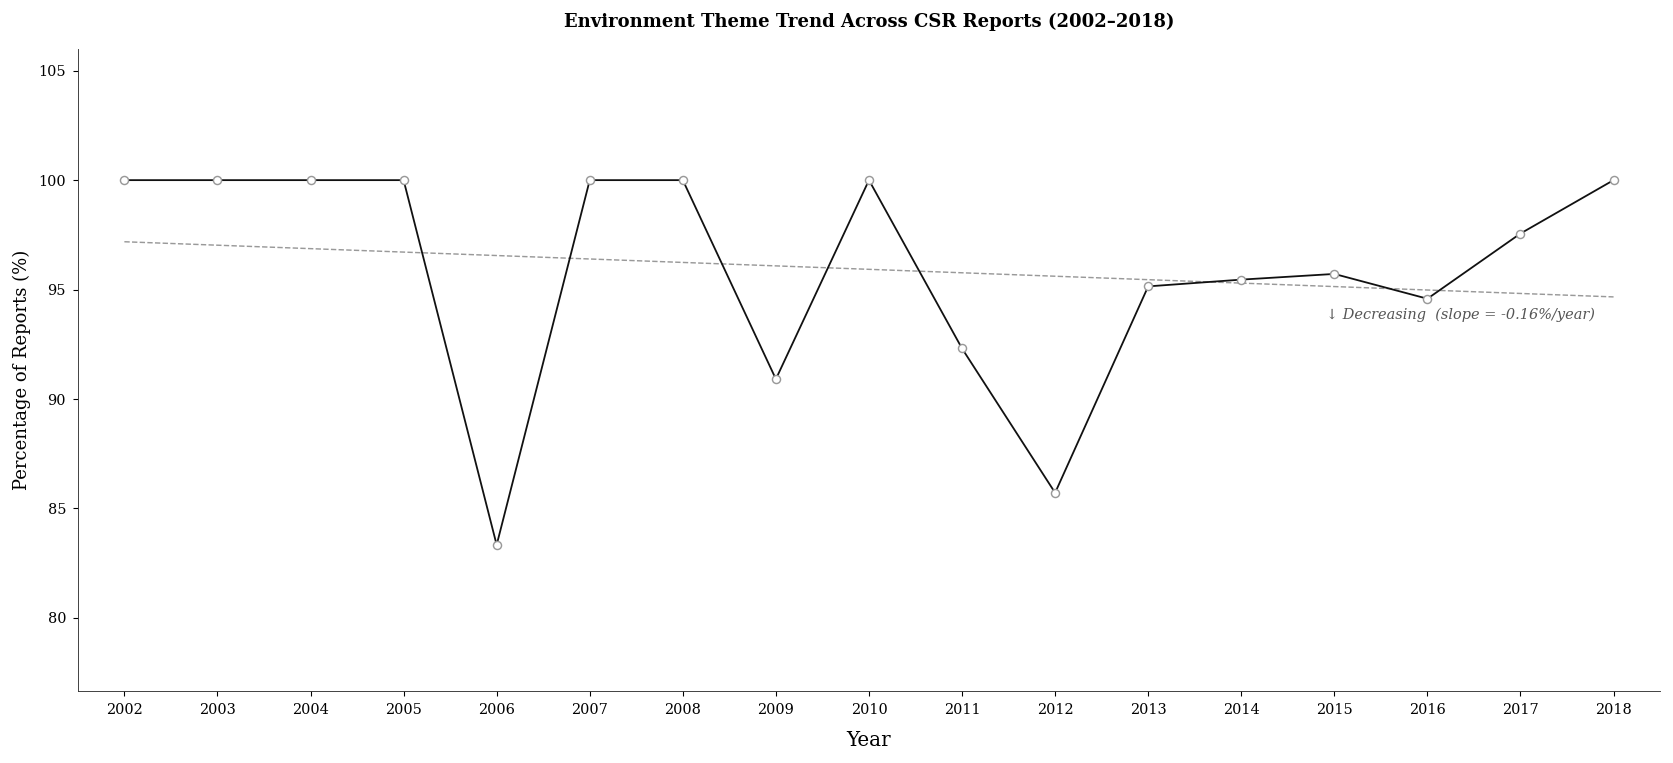

✅ Saved plot4_theme_trends.png
   Trend : ↓ Decreasing (-0.16%/year)


In [135]:
# Cell 9 Figure 4 — Environment Theme Trend Over Time

yearly_themes = []

for year in sorted(df['year'].unique()):
    df_year = df[df['year'] == year]
    count   = 0
    for text in df_year['clean_text']:
        words = set(text.split())
        if len(words.intersection(set(THEMES['Environment']))) >= MIN_MATCHES:
            count += 1
    yearly_themes.append({
        'year'        : year,
        'Environment' : count / len(df_year) * 100
    })

yearly_theme_df = pd.DataFrame(yearly_themes)

slope, intercept, r, p, se = stats.linregress(
    yearly_theme_df['year'], yearly_theme_df['Environment'])
trend_line = slope * yearly_theme_df['year'] + intercept

y_min = yearly_theme_df['Environment'].min() * 0.92
y_max = yearly_theme_df['Environment'].max() * 1.06

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(yearly_theme_df['year'],
        yearly_theme_df['Environment'],
        color=DARK,
        linewidth=1.0,
        zorder=3)

ax.scatter(yearly_theme_df['year'],
           yearly_theme_df['Environment'],
           color=WHITE,
           edgecolors=LIGHT,    
           linewidth=0.8,
           s=20,
           zorder=4)

ax.plot(yearly_theme_df['year'],
        trend_line,
        color=LIGHT,            
        linewidth=0.8,
        linestyle='--',
        zorder=2)

ax.text(yearly_theme_df['year'].max() - 0.2,
        trend_line.iloc[-1] - 0.5,
        f'↓ Decreasing  (slope = {slope:+.2f}%/year)',
        ha='right', va='top',
        fontsize=8,             
        color=MID,              
        style='italic')

ax.set_xlim(yearly_theme_df['year'].min() - 0.5,
            yearly_theme_df['year'].max() + 0.5)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Year', fontsize=11,labelpad=8)
ax.set_ylabel('Percentage of Reports (%)', fontsize=10)
ax.set_title('Environment Theme Trend Across CSR Reports (2002–2018)',
             fontsize=10, pad=12)
ax.set_xticks(yearly_theme_df['year'])
ax.set_xticklabels(yearly_theme_df['year'], rotation=0, fontsize=8)  
ax.tick_params(axis='y', labelsize=8)                                  
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

despine(ax)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'plot4_theme_trends.png'),
            bbox_inches='tight')
plt.show()
print("✅ Saved plot4_theme_trends.png")
print(f"   Trend : ↓ Decreasing ({slope:+.2f}%/year)")